# Urban Detection with Sentinel-1 and Sentinel-2

This notebook converts the Sentinel Hub
[Urban Detection with Sentinel-1 and Sentinel-2](https://custom-scripts.sentinel-hub.com/custom-scripts/data-fusion/urban_s1_s2/)
evalscript by **Monja B. Šebela** into a reusable openEO User-Defined Process (UDP).

Radar is very good at finding buildings and very bad at telling them apart from
other rough, bright things — steep rocky slopes and some vegetation canopies
scatter almost as strongly as a city block. Optical imagery has the opposite
problem: it distinguishes vegetation and water effortlessly but confuses concrete
with bare soil. This algorithm fuses the two, using Sentinel-2 to *rule out* what
Sentinel-1 would otherwise get wrong.

## Overview

In this notebook we will:

1. Connect to an openEO backend that serves Sentinel-2 L1C, Sentinel-2 L2A **and** Sentinel-1 GRD
2. Load all three acquisitions from a single short time window
3. Fuse them into one 10-band cube, resolving the L1C/L2A band-name collision
4. Implement the four-way priority cascade as nested `if_` calls
5. Verify the backend's units and reproduce the whole cascade bit-for-bit in numpy
6. Run the full scene and visualise it
7. Re-run the same graph across three cities
8. Export the process graph as a parameterised UDP

## License

- This notebook is a conversion of a Sentinel Hub evalscript and is licensed under **CC-BY-SA-4.0**.
- Original evalscript: https://custom-scripts.sentinel-hub.com/custom-scripts/data-fusion/urban_s1_s2/
- Source: Sentinel Hub Custom Scripts (CC-BY-SA-4.0)
- Conversion: Development Seed (openEO-UDP project)

## Scientific Background

### Why fuse the two sensors

Buildings are efficient radar reflectors. A vertical wall meeting a flat street
forms a **dihedral corner**, which sends the incoming pulse straight back to the
satellite — the double-bounce effect — so built-up areas are bright in both VV
and VH. The trouble is that this brightness is not unique to cities: steep
terrain facing the sensor, exposed rock and some dense canopies produce similar
returns. A radar-only threshold therefore over-detects, which the original script
documents as its main weakness.

Sentinel-2 resolves most of that ambiguity, because the confusing surfaces are
exactly the ones optical sensors identify well:

- **NDVI** = (B08 − B04) / (B08 + B04) — healthy vegetation reflects strongly in
  the near infrared and absorbs red, so NDVI > 0.5 marks dense vegetation.
- **NDMI** = (B08 − B11) / (B08 + B11) — water absorbs SWIR (B11) far more than
  NIR (B08), so NDMI > 0 marks water and moist surfaces.

### The four-way cascade

The original `evaluatePixel` returns on the first matching condition, so the
branches form a strict priority order. Only one renders each pixel:

| Priority | Condition | Output | Appearance |
| --- | --- | --- | --- |
| 1 | `NDVI > 0.5` | `[3·B04, 3·B03, 3·B02]` from **L2A** | brightened true colour — vegetation reads green |
| 2 | `NDMI > 0` | `[3·B04, 3·B03, 4·B02]` from **L2A** | true colour with a boosted blue — water reads blue |
| 3 | `VH > 0.2` or `VV > 0.2` | `[VH·5.5, VV, VH·8]` from **S1** | backscatter false colour — built-up reads purple/magenta |
| 4 | otherwise | `[3·B04−0.2, 3·B03−0.2, 3·B02−0.2]` from **L1C** | darkened true colour — bare soil, rock, desert |

Vegetation and water are tested *first*, so a bright-backscatter pixel that is
also vegetated or wet never reaches the built-up branch. That ordering is the
whole point of the fusion: Sentinel-2 masks out the surfaces Sentinel-1 would
misread.

Branch 3 is the same VH/VV false-colour rendering used by the author's
[Urban Areas script](https://custom-scripts.sentinel-hub.com/custom-scripts/sentinel-1/urban_areas/);
because blue carries `VH·8` and red only `VH·5.5`, buildings come out purple,
shading toward white where VV is also strong.

### Why L1C *and* L2A

The original reads the indices from **L1C** (top of atmosphere) but renders the
vegetation and water branches from **L2A** (bottom of atmosphere, atmospherically
corrected), falling back to L1C for branch 4. We keep that split rather than
using one product for everything: the index thresholds were tuned against TOA
reflectance, and TOA NDVI runs lower than BOA NDVI because atmospheric path
radiance inflates the red band. Substituting L2A into the indices would silently
shift the 0.5 vegetation threshold.

## Import Required Libraries

We begin by importing the necessary Python libraries for data processing,
visualization, and parameter management.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import rioxarray
from matplotlib.patches import Patch
from openeo.processes import array_create, if_, or_

# openEO UDP parameter management system
from openeo_udp import ParameterManager

## Load Parameters and Connect to openEO Backend

Load algorithm parameters from the co-located parameter file and connect to an
openEO backend.

In [2]:
# Initialize the algorithm ID for UDP registration
_algorithm_id = "urban_s1_s2"

# Initialize parameter manager
param_manager = ParameterManager("urban_s1_s2.params.py")

# Display available options using the built-in helper
param_manager.print_options("urban detection (S1/S2 fusion) algorithm")

Available parameter sets for urban detection (S1/S2 fusion) algorithm:
  1. cairo_egypt: Cairo, Egypt
  2. bologna_italy: Bologna, Italy
  3. paris_france: Paris, France

Available OpenEO endpoints:
  1. localhost_dev: http://localhost:8082/
  2. ds_development: https://openeo.ds.io/
  3. copernicus_dataspace: https://openeo.dataspace.copernicus.eu/
  4. eopf_explorer: https://api.explorer.eopf.copernicus.eu/openeo

💡 Tip: Use param_manager.interactive_parameter_selection() for interactive selection,
or param_manager.quick_connect('set_name', 'endpoint') for direct connection.
To change selections, use the interactive widgets in the next cell.


In [3]:
# This fusion needs a backend serving all three products — Sentinel-2 L1C,
# Sentinel-2 L2A and Sentinel-1 GRD. CDSE serves all three, and serves S1 GRD as
# calibrated *linear* backscatter, which the 0.2 threshold and the 5.5/8 display
# gains assume. Keep the endpoint in a variable so the L2A and S1
# collection/bands can be routed through the SAME endpoint mapper below.
_endpoint = "copernicus_dataspace"
_primary_set = "cairo_egypt"

connection, current_params = param_manager.quick_connect(
    param_set=_primary_set,
    endpoint=_endpoint,
)

🔄 Connecting to copernicus_dataspace...
📍 Using parameter set: cairo_egypt
Authenticated using refresh token.
✅ Successfully connected to copernicus_dataspace
✅ Parameters loaded and mapped for: Cairo, Egypt
🔄 Parameters mapped for endpoint copernicus_dataspace:
  collection: sentinel-2-l1c -> SENTINEL2_L1C
  bands: ['b02', 'b03', 'b04', 'b08', 'b11'] -> ['B02', 'B03', 'B04', 'B08', 'B11']


## Load the Three Acquisitions

All three come from the same short window. The **L1C** collection and bands flow
through the standard parameter mapping (which also injects `reflectance_scale`
and the dimension names); the **L2A** and **Sentinel-1** collection/bands are
routed through the same endpoint mapper explicitly, because the automatic mapping
only handles the single `collection`/`bands` pair.

`bounding_box`, `time` and `cloud_cover` stay as **`Parameter` objects** so the
exported graph keeps its `{"from_parameter": ...}` references and remains a
reusable UDP. Each cube is reduced over time with `mean`, collapsing the window
to the single pass it contains.

In [4]:
bbox = current_params["bounding_box"]
time = current_params["time"]
bands_dim = current_params["bands_dimension"]
time_dim = current_params["time_dimension"]
scale = current_params["reflectance_scale"]  # 10000.0 on CDSE

# Route the two secondary collections through the same endpoint mapper so the
# canonical ids resolve to this backend's native names.
_l2a = param_manager.apply_endpoint_mapping(
    {"collection": current_params["l2a_collection"], "bands": current_params["l2a_bands"]},
    _endpoint,
)
_s1 = param_manager.apply_endpoint_mapping(
    {"collection": current_params["s1_collection"], "bands": current_params["s1_bands"]},
    _endpoint,
)

# --- Sentinel-2 L1C: the NDVI/NDMI masks and the fallback true colour ---
l1c = connection.load_collection(
    current_params["collection"].default,
    temporal_extent=time,
    spatial_extent=bbox,
    bands=current_params["bands"].default,
    properties={
        "eo:cloud_cover": lambda x: x <= current_params["cloud_cover"],
    },
).reduce_dimension(dimension=time_dim, reducer="mean")

# --- Sentinel-1 GRD: the built-up test ---
s1 = connection.load_collection(
    _s1["collection"].default,
    temporal_extent=time,
    spatial_extent=bbox,
    bands=_s1["bands"].default,
).reduce_dimension(dimension=time_dim, reducer="mean")

# --- Sentinel-2 L2A: true colour for the vegetation and water branches ---
l2a = connection.load_collection(
    _l2a["collection"].default,
    temporal_extent=time,
    spatial_extent=bbox,
    bands=_l2a["bands"].default,
    properties={
        "eo:cloud_cover": lambda x: x <= current_params["cloud_cover"],
    },
).reduce_dimension(dimension=time_dim, reducer="mean")

print(f"L1C bands: {current_params['bands'].default}")
print(f"S1  bands: {_s1['bands'].default}")
print(f"L2A bands: {_l2a['bands'].default}")
print("✅ Loaded L1C, S1 and L2A")

L1C bands: ['B02', 'B03', 'B04', 'B08', 'B11']
S1  bands: ['VH', 'VV']
L2A bands: ['B02', 'B03', 'B04']
✅ Loaded L1C, S1 and L2A


## Fuse the Three Sensors into One Cube

The per-pixel cascade needs all ten inputs available at once. Two obstacles:

1. **L1C and L2A both expose `B02`/`B03`/`B04`**, which would collide on merge.
   Sentinel-1's `VH`/`VV` are already unique, so only the L2A trio needs
   relabelling: `.band(...)` drops the bands dimension and `add_dimension`
   re-attaches it under a distinct label. (`rename_labels` would be more direct
   but is not available on CDSE.)
2. **Sentinel-1 is on a different grid**, so it is `resample_cube_spatial`-aligned
   onto the L1C grid before merging.

The resulting band order is fixed by construction and asserted below, because the
classification callback reads the bands positionally.

In [5]:
# Resolve canonical band ids to this backend's native names rather than guessing.
l1c_bands = param_manager.band_name_map(current_params)
s1_names = dict(
    zip(current_params["s1_bands"].default, _s1["bands"].default, strict=True)
)
l2a_names = dict(
    zip(current_params["l2a_bands"].default, _l2a["bands"].default, strict=True)
)

# Relabel the three L2A bands so they cannot collide with their L1C namesakes.
l2a_relabelled = (
    l2a.band(l2a_names["b04"]).add_dimension(name=bands_dim, label="l2a_b04", type="bands")
    .merge_cubes(
        l2a.band(l2a_names["b03"]).add_dimension(name=bands_dim, label="l2a_b03", type="bands")
    )
    .merge_cubes(
        l2a.band(l2a_names["b02"]).add_dimension(name=bands_dim, label="l2a_b02", type="bands")
    )
)

# Align the other two cubes onto the L1C grid, then merge everything.
fused = l1c.merge_cubes(s1.resample_cube_spatial(l1c, method="near")).merge_cubes(
    l2a_relabelled.resample_cube_spatial(l1c, method="near")
)

EXPECTED_BANDS = [
    l1c_bands["b02"], l1c_bands["b03"], l1c_bands["b04"],
    l1c_bands["b08"], l1c_bands["b11"],
    s1_names["vh"], s1_names["vv"],
    "l2a_b04", "l2a_b03", "l2a_b02",
]

fused_bands = fused.metadata.band_names
print("Fused band order:", fused_bands)
assert fused_bands == EXPECTED_BANDS, f"expected {EXPECTED_BANDS}, got {fused_bands}"

Fused band order: ['B02', 'B03', 'B04', 'B08', 'B11', 'VH', 'VV', 'l2a_b04', 'l2a_b03', 'l2a_b02']


## The Classification Cascade

A single `apply_dimension` over the bands dimension runs the original
`evaluatePixel`. openEO has no early `return`, so the cascade is built the other
way round: start from the lowest-priority branch and let each higher-priority
`if_` overwrite it. Applying them in the order fallback → built-up → water →
vegetation reproduces the original's first-match-wins semantics exactly.

Sentinel-2 reflectance is divided by `reflectance_scale` to recover the 0–1 range
the original assumes; Sentinel-1 backscatter is already linear and is used as-is.

In [6]:
# Thresholds and display gains, verbatim from the original evalscript.
NDVI_VEGETATION = 0.5
NDMI_WATER = 0.0
S1_BUILTUP = 0.2


def urban_classify(data):
    """Four-way priority cascade — vegetation > water > built-up > fallback."""
    # Bands in EXPECTED_BANDS order. S2 -> reflectance; S1 -> raw backscatter.
    b02, b03, b04 = data[0] / scale, data[1] / scale, data[2] / scale
    b08, b11 = data[3] / scale, data[4] / scale
    vh, vv = data[5], data[6]
    l2a_b04, l2a_b03, l2a_b02 = data[7] / scale, data[8] / scale, data[9] / scale

    ndvi = (b08 - b04) / (b08 + b04)
    ndmi = (b08 - b11) / (b08 + b11)

    # Priority 4 (lowest): darkened L1C true colour for bare soil, rock, desert.
    red, green, blue = 3 * b04 - 0.2, 3 * b03 - 0.2, 3 * b02 - 0.2

    # Priority 3: built-up — bright in either polarization.
    builtup = or_(vh > S1_BUILTUP, vv > S1_BUILTUP)
    red = if_(builtup, vh * 5.5, red)
    green = if_(builtup, vv, green)
    blue = if_(builtup, vh * 8, blue)

    # Priority 2: water and moist surfaces — L2A true colour, blue boosted to 4x.
    water = ndmi > NDMI_WATER
    red = if_(water, 3 * l2a_b04, red)
    green = if_(water, 3 * l2a_b03, green)
    blue = if_(water, 4 * l2a_b02, blue)

    # Priority 1 (highest): dense vegetation — plain L2A true colour.
    vegetation = ndvi > NDVI_VEGETATION
    red = if_(vegetation, 3 * l2a_b04, red)
    green = if_(vegetation, 3 * l2a_b03, green)
    blue = if_(vegetation, 3 * l2a_b02, blue)

    return array_create([red, green, blue])


urban_rgb = fused.apply_dimension(dimension=bands_dim, process=urban_classify)

# The evalscript emits 0-1 floats that Sentinel Hub renders as 8-bit RGB;
# linear_scale_range does the same here and clips out-of-range values.
urban_rgb = urban_rgb.linear_scale_range(
    input_min=0, input_max=1, output_min=0, output_max=255
)

urban_result = urban_rgb.save_result("GTiff")

## Verify Units and Reproduce the Cascade

**This runs before the full-scene request on purpose.** Two things can go wrong
silently:

- **Sentinel-1 units.** The `0.2` threshold and the `5.5`/`8` gains assume
  calibrated *linear* backscatter in roughly 0–1. A backend serving raw Level-1
  digital numbers (integers in the hundreds) would put every pixel over the
  threshold, and one serving decibels (negative) would put none over it. Either
  way the built-up branch collapses without raising an error.
- **Sentinel-2 scaling.** A wrong `reflectance_scale` shifts NDVI and NDMI, and
  the true-colour branches saturate or go black.

So we pull a small window first, assert the units are what the algorithm expects,
then reproduce the entire four-way cascade in numpy and compare it against the
backend's output pixel by pixel. Since the classification is a nested chain of
`if_` calls, this is the only way to be sure the branch priorities came out right.

In [7]:
_bb = current_params["bounding_box"].default
_cx = (_bb["west"] + _bb["east"]) / 2
_cy = (_bb["south"] + _bb["north"]) / 2
check_bbox = {
    "west": round(_cx - 0.02, 4),
    "east": round(_cx + 0.02, 4),
    "south": round(_cy - 0.02, 4),
    "north": round(_cy + 0.02, 4),
}


def build_fused(extent, temporal_extent, params, l2a_spec, s1_spec):
    """Build the fused 10-band cube for an explicit extent (same steps as above)."""
    def _load(collection, band_list, with_cloud):
        kwargs = {}
        if with_cloud:
            kwargs["properties"] = {
                "eo:cloud_cover": lambda x: x <= params["cloud_cover"]
            }
        return connection.load_collection(
            collection,
            temporal_extent=temporal_extent,
            spatial_extent=extent,
            bands=band_list,
            **kwargs,
        ).reduce_dimension(dimension=time_dim, reducer="mean")

    _l1c = _load(params["collection"].default, params["bands"].default, True)
    _s1c = _load(s1_spec["collection"].default, s1_spec["bands"].default, False)
    _l2ac = _load(l2a_spec["collection"].default, l2a_spec["bands"].default, True)

    _names = dict(
        zip(params["l2a_bands"].default, l2a_spec["bands"].default, strict=True)
    )
    _relabelled = (
        _l2ac.band(_names["b04"]).add_dimension(name=bands_dim, label="l2a_b04", type="bands")
        .merge_cubes(
            _l2ac.band(_names["b03"]).add_dimension(name=bands_dim, label="l2a_b03", type="bands")
        )
        .merge_cubes(
            _l2ac.band(_names["b02"]).add_dimension(name=bands_dim, label="l2a_b02", type="bands")
        )
    )
    return _l1c.merge_cubes(_s1c.resample_cube_spatial(_l1c, method="near")).merge_cubes(
        _relabelled.resample_cube_spatial(_l1c, method="near")
    )


check_fused = build_fused(
    check_bbox, current_params["time"].default, current_params, _l2a, _s1
)

# The bbox/time are already concrete here, but cloud_cover is still a Parameter
# ref, and synchronous execution rejects unresolved refs — so resolve both cubes.
_raw = check_fused.save_result("GTiff")
param_manager.resolve(_raw, current_params).download("urban_s1_s2_check_fused.tif")

# 2. the classified composite over the identical window
_comp = check_fused.apply_dimension(
    dimension=bands_dim, process=urban_classify
).linear_scale_range(
    input_min=0, input_max=1, output_min=0, output_max=255
).save_result("GTiff")
param_manager.resolve(_comp, current_params).download("urban_s1_s2_check_rgb.tif")

print("✅ Downloaded validation window:", check_bbox)

✅ Downloaded validation window: {'west': 31.23, 'east': 31.27, 'south': 30.03, 'north': 30.07}


In [8]:
_f_da = rioxarray.open_rasterio("urban_s1_s2_check_fused.tif")
f = _f_da.values.astype("float64")
if _f_da.rio.nodata is not None and np.isfinite(_f_da.rio.nodata):
    f[f == _f_da.rio.nodata] = np.nan

_c_da = rioxarray.open_rasterio("urban_s1_s2_check_rgb.tif")
comp = _c_da.values.astype("float64")
if _c_da.rio.nodata is not None and np.isfinite(_c_da.rio.nodata):
    comp[comp == _c_da.rio.nodata] = np.nan

# Every band must be present for a pixel to be comparable — the three cubes have
# slightly different footprints after resampling.
valid = np.all(np.isfinite(f), axis=0) & np.all(np.isfinite(comp), axis=0)
print(f"comparable pixels: {valid.mean():.2%}")

b02, b03, b04, b08, b11 = (f[i] / scale for i in range(5))
vh, vv = f[5], f[6]
l2a_b04, l2a_b03, l2a_b02 = f[7] / scale, f[8] / scale, f[9] / scale

# --- Unit guards -------------------------------------------------------------
# Linear backscatter is non-negative and sits mostly below 1; only strong
# double-bounce targets exceed it, so test a high percentile rather than the max.
_vh99 = float(np.nanpercentile(vh[valid], 99))
assert np.nanmin(vh[valid]) >= 0, (
    "Sentinel-1 VH contains negative values, so this backend serves decibels "
    "rather than linear backscatter. The 0.2 threshold and the 5.5/8 gains "
    "assume linear; convert with 10**(dB/10) or use a backend serving linear."
)
assert _vh99 <= 5.0, (
    f"Sentinel-1 VH 99th percentile is {_vh99:.1f}, far outside the 0-1 range of "
    "calibrated linear backscatter — this backend appears to serve raw Level-1 "
    "digital numbers, which would push every pixel past the 0.2 built-up "
    "threshold. Use a backend serving calibrated backscatter (CDSE does)."
)

# Reflectance after scaling must land in 0-1 (a little over 1 for specular glint).
_r99 = float(np.nanpercentile(b04[valid], 99))
assert 0 <= _r99 <= 1.5, (
    f"Sentinel-2 B04 99th percentile is {_r99:.2f} after dividing by "
    f"reflectance_scale={scale}. Expected roughly 0-1 reflectance; the scale for "
    "this backend looks wrong, which would corrupt NDVI, NDMI and the colours."
)
print(f"✅ Units check out — VH p99 {_vh99:.3f}, B04 reflectance p99 {_r99:.3f}")

comparable pixels: 100.00%
✅ Units check out — VH p99 0.463, B04 reflectance p99 0.327


Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.


In [9]:
# --- Reproduce the full cascade in numpy ------------------------------------
ndvi = (b08 - b04) / (b08 + b04)
ndmi = (b08 - b11) / (b08 + b11)

# Mutually exclusive branch masks, in the original's priority order.
m_veg = ndvi > NDVI_VEGETATION
m_water = (~m_veg) & (ndmi > NDMI_WATER)
m_builtup = (~m_veg) & (~m_water) & ((vh > S1_BUILTUP) | (vv > S1_BUILTUP))
m_fallback = ~(m_veg | m_water | m_builtup)

shares = {
    "vegetation": m_veg[valid].mean(),
    "water": m_water[valid].mean(),
    "built-up": m_builtup[valid].mean(),
    "fallback": m_fallback[valid].mean(),
}
print("Branch shares in the validation window:")
for name, share in shares.items():
    print(f"  {name:<12} {share:6.1%}")
assert abs(sum(shares.values()) - 1.0) < 1e-9, "branches must partition the scene"

want_r = np.where(m_veg | m_water, 3 * l2a_b04, np.where(m_builtup, vh * 5.5, 3 * b04 - 0.2))
want_g = np.where(m_veg | m_water, 3 * l2a_b03, np.where(m_builtup, vv, 3 * b03 - 0.2))
want_b = np.where(
    m_veg, 3 * l2a_b02,
    np.where(m_water, 4 * l2a_b02, np.where(m_builtup, vh * 8, 3 * b02 - 0.2)),
)

# The backend truncates the scaled result when writing the integer raster, so the
# expected value is floor(clip(x, 0, 1) * 255) — an exact match, not a tolerance.
for channel, want in enumerate([want_r, want_g, want_b]):
    expected = np.floor(np.clip(want, 0, 1) * 255)
    match = np.mean(comp[channel][valid] == expected[valid])
    worst = np.abs(comp[channel][valid] - expected[valid]).max()
    print(f"channel {'RGB'[channel]}: exact match {match:.4%}, max deviation {worst:g} DN")
    assert match == 1.0, f"channel {'RGB'[channel]} differs from the reference cascade"

print("✅ openEO reproduces the four-way cascade exactly, pixel for pixel")

Branch shares in the validation window:
  vegetation     0.5%
  water         11.2%
  built-up      50.3%
  fallback      38.0%
channel R: exact match 100.0000%, max deviation 0 DN
channel G: exact match 100.0000%, max deviation 0 DN
channel B: exact match 100.0000%, max deviation 0 DN
✅ openEO reproduces the four-way cascade exactly, pixel for pixel


## Execute and Download

In [10]:
_location_slug = (
    current_params["location_name"].split(",")[0].strip().lower().replace(" ", "_")
)
rgb_filename = f"{_algorithm_id}_{_location_slug}.tif"

# Synchronous execution (POST /result) does not accept unresolved Parameter refs,
# so materialise them here. `urban_result` itself keeps them for the UDP export.
param_manager.resolve(urban_result, current_params).download(rgb_filename)
print(f"✅ Downloaded {rgb_filename}")

✅ Downloaded urban_s1_s2_cairo.tif


## Visualize the Result

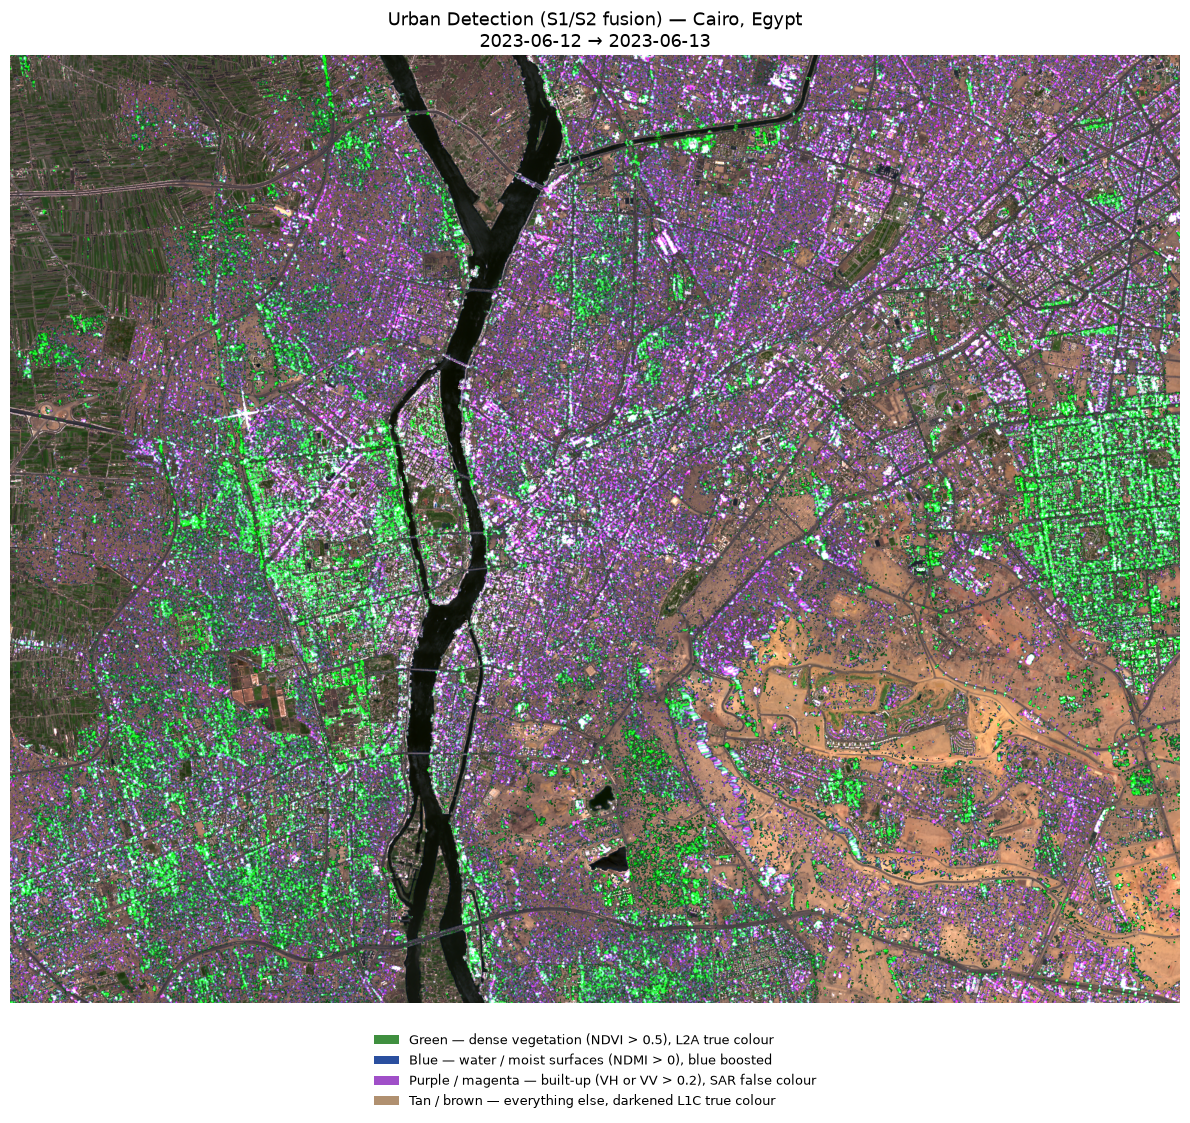

In [11]:
def read_rgb(path):
    """Read a 3-band composite as float RGB in 0-1, with no-data mapped to NaN."""
    da = rioxarray.open_rasterio(path)
    arr = da.values.astype("float32")
    if da.rio.nodata is not None:
        arr[arr == da.rio.nodata] = np.nan
    return np.transpose(arr, (1, 2, 0)) / 255.0


BRANCH_LEGEND = [
    Patch(facecolor="#3f8f3f", label="Green — dense vegetation (NDVI > 0.5), L2A true colour"),
    Patch(facecolor="#2a4f9f", label="Blue — water / moist surfaces (NDMI > 0), blue boosted"),
    Patch(facecolor="#a04fc8", label="Purple / magenta — built-up (VH or VV > 0.2), SAR false colour"),
    Patch(facecolor="#b09070", label="Tan / brown — everything else, darkened L1C true colour"),
]

rgb = read_rgb(rgb_filename)

preview_fig, ax = plt.subplots(figsize=(13, 11))
ax.imshow(np.nan_to_num(rgb))
ax.set_title(
    f"Urban Detection (S1/S2 fusion) — {current_params['location_name']}\n"
    f"{current_params['time'].default[0]} → {current_params['time'].default[1]}",
    fontsize=13,
)
ax.axis("off")
ax.legend(
    handles=BRANCH_LEGEND,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.02),
    fontsize=9,
    frameon=False,
)
plt.tight_layout()
plt.show()

## Validation Across Multiple Cities

The same graph is re-run on the two other parameter sets, which stress the
algorithm differently:

- **Bologna, Italy** — a compact city ringed by intensively farmed Po valley
  cropland, so the vegetation branch dominates the surroundings.
- **Paris, France** — a dense historic core with the Seine and large parks, and a
  sharp gradient from continuous built-up to suburbs.

In [12]:
validation_sets = ["bologna_italy", "paris_france"]
validation_outputs = {}

for set_name in validation_sets:
    _, val_params = param_manager.quick_connect(
        param_set=set_name, endpoint=_endpoint, silent=True
    )
    val_l2a = param_manager.apply_endpoint_mapping(
        {"collection": val_params["l2a_collection"], "bands": val_params["l2a_bands"]},
        _endpoint,
    )
    val_s1 = param_manager.apply_endpoint_mapping(
        {"collection": val_params["s1_collection"], "bands": val_params["s1_bands"]},
        _endpoint,
    )
    val_cube = build_fused(
        val_params["bounding_box"], val_params["time"], val_params, val_l2a, val_s1
    )
    val_result = val_cube.apply_dimension(
        dimension=bands_dim, process=urban_classify
    ).linear_scale_range(
        input_min=0, input_max=1, output_min=0, output_max=255
    ).save_result("GTiff")

    val_file = f"{_algorithm_id}_{set_name}.tif"
    param_manager.resolve(val_result, val_params).download(val_file)
    validation_outputs[set_name] = (val_file, val_params)
    print(f"✅ {set_name}: {val_file}")

# Restore the primary parameter set for the export section below.
param_manager.use_parameter_set(_primary_set)

Authenticated using refresh token.
✅ bologna_italy: urban_s1_s2_bologna_italy.tif
Authenticated using refresh token.
✅ paris_france: urban_s1_s2_paris_france.tif


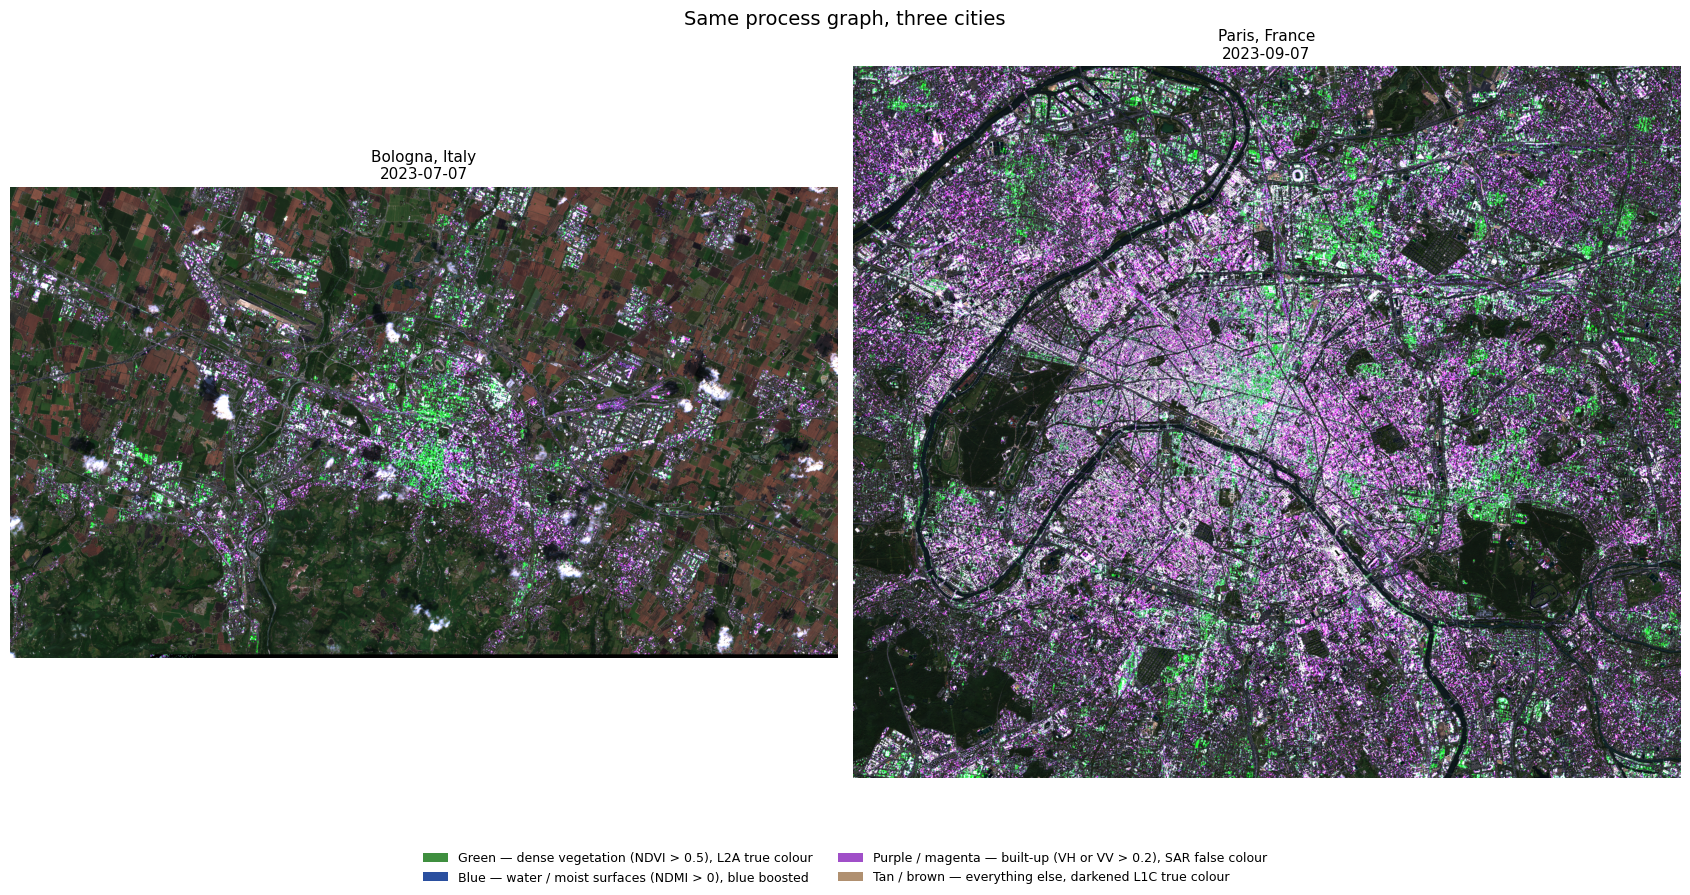

In [13]:
fig, axes = plt.subplots(1, len(validation_outputs), figsize=(17, 9))

for ax, set_name in zip(np.atleast_1d(axes), validation_sets, strict=True):
    val_file, val_params = validation_outputs[set_name]
    ax.imshow(np.nan_to_num(read_rgb(val_file)))
    ax.set_title(
        f"{val_params['location_name']}\n{val_params['time'].default[0]}", fontsize=11
    )
    ax.axis("off")

fig.suptitle("Same process graph, three cities", fontsize=14)
fig.legend(
    handles=BRANCH_LEGEND, loc="lower center", ncol=2, fontsize=9, frameon=False
)
plt.tight_layout(rect=(0, 0.08, 1, 1))
plt.show()

### What the validation shows

**Cairo** exercises all four branches in a single frame: the Nile and the
irrigation canals render dark blue, the Delta farmland green, the continuous
built-up fabric of Cairo and Giza purple, and the desert west of the Pyramids tan
from the fallback branch. The boundary between city and desert is crisp, which is
the clearest evidence the fusion is doing its job — a radar-only threshold would
have flagged much of the rocky desert margin as built-up.

**Bologna** and **Paris** show the same behaviour in a temperate setting: the
urban core is purple, parks and cropland green, the Seine blue. In Bologna the
July cropland is largely post-harvest, so a good deal of it falls through to the
tan fallback rather than the vegetation branch.

Note the **speckle**: the built-up branch renders raw SAR backscatter, which is
inherently noisy, and neighbouring pixels flip between branches wherever a value
sits near a threshold. The original applies no speckle filter and neither does
this conversion.

### Edge cases

- **No-data.** The three cubes have slightly different footprints, so edge pixels
  can be valid in one sensor and absent in another. Those propagate as no-data
  rather than failing; the numerical check above compares only pixels valid in
  all ten bands, and reports what fraction that was.
- **Division by zero.** NDVI and NDMI divide by `B08 + B04` and `B08 + B11`. Both
  sums are zero only where the bands are simultaneously zero, i.e. already
  no-data; openEO propagates NaN rather than raising, and such pixels fall
  through to the fallback branch.
- **Out-of-range output.** `3 × reflectance` exceeds 1 over bright roofs and
  `VH × 8` over strong double-bounce targets. `linear_scale_range` clips to 255
  rather than wrapping. The fallback branch's `− 0.2` offset can go negative over
  dark surfaces and is clipped to 0.
- **Cloud.** A cloudy pixel has high reflectance in all visible bands and low
  NDVI/NDMI, so it reaches the built-up test and is classified by radar alone —
  clouds are transparent to C-band, so the answer is usually still right, but the
  *colour* comes from the SAR branch. Keep `cloud_cover` low.

## Limitations and Differences from the Original

- **Three collections, one backend.** The fusion needs Sentinel-2 L1C, Sentinel-2
  L2A and Sentinel-1 GRD from the same provider. CDSE serves all three. This
  conversion added `sentinel-2-l1c` to the repository's canonical collection
  registry; endpoints without a verified L1C mapping raise
  `UnsupportedCollectionError` rather than guessing at native band names.
- **Backscatter convention is a hard requirement.** The `0.2` threshold and the
  `5.5`/`8` gains are meaningful only for calibrated linear backscatter. A
  backend serving raw digital numbers or decibels silently destroys the built-up
  branch; the unit guard above turns that into an explicit failure.
- **`orthorectify: "TRUE"` has no direct openEO equivalent.** The original
  requests orthorectification of the S1 input. Here we inherit whatever
  ortho-rectification the backend's GRD product already applies (CDSE serves an
  ortho-corrected product) and additionally `resample_cube_spatial` onto the L1C
  grid. Residual terrain-induced misregistration is not corrected, which matters
  most in exactly the steep terrain where the algorithm already over-detects.
- **Two sensors, two acquisition times.** The original implies a single fused
  observation. In practice S1 and S2 rarely acquire simultaneously, so each
  parameter set uses a window containing one pass of each — same day for Cairo,
  one to two days apart elsewhere. Anything that genuinely changes in between
  (harvest, flooding, construction) is misclassified.
- **Over-detection on steep terrain and rock persists.** The optical masks remove
  vegetation and water, not bright rock. The author documents this, and the
  Cairo desert margin still shows scattered purple on rocky outcrops.
- **NDMI > 0 is a moisture test, not a water test.** It catches wet soil and
  irrigated fields as well as open water, so the "water" branch is broader than
  its name suggests.
- **No speckle filtering**, exactly as in the original.

## Export the Process Graph

The exported UDP is the classified RGB composite. Its parameters are the runtime
knobs — area of interest, time window and cloud-cover ceiling — while the three
collections, their bands and every threshold stay intrinsic to the algorithm.

In [12]:
# Notebook metadata used to build the OGC API record. Tagged so
# `populate_record.py` can find and `exec()` this cell by tag, not position --
# which means it runs with its own fresh globals, so everything it needs is
# recomputed here rather than referencing state from earlier cells.
from pathlib import Path

from openeo_udp import ParameterManager
from openeo_udp.endpoints import get_endpoint_config

_algorithm_id = "urban_s1_s2"

_repo_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "notebooks").exists())
_nb_href = f"{(Path.cwd() / f'{_algorithm_id}.ipynb').relative_to(_repo_root)}"

_param_set = "cairo_egypt"
_endpoint_name = "copernicus_dataspace"
_param_manager = ParameterManager(f"{_algorithm_id}.params.py")
_raw_params = _param_manager.get_parameter_set(_param_set)

# Endpoint mapping resolves the backend-native collection id (which can differ
# from the canonical id in the .params.py file), matching what the earlier
# cells actually load via quick_connect().
_mapped_params = _param_manager.apply_endpoint_mapping(_raw_params, _endpoint_name)
_endpoint_config = get_endpoint_config(_endpoint_name)

# Notebook metadata
metadata = {
    "id": _algorithm_id,
    "title": "Urban Detection (S1/S2 Fusion)",
    "preview_title": "Urban Detection (S1/S2 Fusion)",
    "description": (
        "Multi-sensor data fusion that maps built-up areas by thresholding "
        "Sentinel-1 backscatter after masking out vegetation and water with "
        "Sentinel-2 NDVI and NDMI, rendering each pixel from whichever sensor "
        "best describes it."
    ),
    "keywords": ["Land Use/Land Cover Classification", "Vegetation", "Normalized Difference Vegetation Index (NDVI)", "Radar", "Sentinel-1", "Sentinel-2"],
    "themes": ["URBAN AREAS", "LAND COVER", "HUMAN SETTLEMENTS", "REMOTE SENSING", "Sentinel-1 SAR", "Sentinel-2 MSI"],
    "created": "2026-07-29T00:00:00Z",
    "updated": "2026-08-14T00:00:00Z",
    "license": "CC-BY-SA-4.0",
    "openeo_backend_title": _endpoint_config["name"],
    "openeo_backend_url": _endpoint_config["url"],
    "notebook_github_location": _nb_href,
    "collection_id": _mapped_params["collection"].default,
    "attribution": {
        "original_script": "https://custom-scripts.sentinel-hub.com/custom-scripts/data-fusion/urban_s1_s2/",
        "authors": ["Monja B. Šebela"],
        "source_repository": "https://github.com/sentinel-hub/custom-scripts",
    },
}


In [13]:
# Export the process graph for reuse as a parameterized UDP
import json

from algorithm_registration.register_algorithm import register

process_graph = {
    "process_graph": urban_result.flat_graph(),
    "parameters": [
        current_params["bounding_box"].to_dict(),
        current_params["time"].to_dict(),
        current_params["cloud_cover"].to_dict(),
    ],
    "id": _algorithm_id,
    "summary": "Urban detection by Sentinel-1/Sentinel-2 data fusion using openEO.",
    "description": metadata["description"],
}

# Save the process graph
udp_path = Path(f"{_algorithm_id}.json")
with open(udp_path, "w") as f:
    json.dump(process_graph, f, indent=2)

register(
    notebook_path=Path.cwd() / f"{_algorithm_id}.ipynb",
    udp_path=Path(f"{_algorithm_id}.json"),
    preview_fig=preview_fig
)


Algorithm directory: algorithm_registration/urban_s1_s2
UDP registered: algorithm_registration/urban_s1_s2/openeo_udp/urban_s1_s2.json
Preview registered from figure: algorithm_registration/urban_s1_s2/records/preview.png
Record written: algorithm_registration/urban_s1_s2/records/urban_s1_s2.json
Thumbnail written: algorithm_registration/urban_s1_s2/records/thumbnail.png
Commit all the records before pushing to openeo-udp repository


PosixPath('algorithm_registration/urban_s1_s2')

## References and Attribution

**Original Script:** [Urban Detection with Sentinel-1 and Sentinel-2](https://custom-scripts.sentinel-hub.com/custom-scripts/data-fusion/urban_s1_s2/)

**Author:** Monja B. Šebela

**Source Repository:** [Sentinel Hub Custom Scripts](https://github.com/sentinel-hub/custom-scripts)

The built-up rendering `[VH·5.5, VV, VH·8]` is shared with the same author's
[Urban Areas script](https://custom-scripts.sentinel-hub.com/custom-scripts/sentinel-1/urban_areas/),
converted separately in this repository.

### Scientific references

- Ulaby, F. T., Moore, R. K., Fung, A. K. (1982). *Microwave Remote Sensing:
  Active and Passive, Vol. II.* Addison-Wesley. — double-bounce scattering from
  building/ground dihedrals.
- Esch, T. et al. (2017). Breaking new ground in mapping human settlements from
  space — the Global Urban Footprint. *ISPRS Journal of Photogrammetry and Remote
  Sensing*, 134, 30–42. — SAR-based settlement mapping and its confusion classes.
- Gao, B.-C. (1996). NDWI — a normalized difference water index for remote sensing
  of vegetation liquid water from space. *Remote Sensing of Environment*, 58,
  257–266. — the NIR/SWIR moisture index used here as NDMI.

### openEO Conversion

- **Conversion Date**: 29 July 2026
- **openEO Framework**: Adapted for the openEO API and process graph structure
- **Backend Tested**: CDSE (Copernicus Data Space Ecosystem)
- **License**: CC-BY-SA-4.0

## Conclusion

This notebook converts the Urban Detection (S1/S2 fusion) evalscript into an
openEO User-Defined Process. The implementation:

✅ **Fuses three acquisitions across two sensors** (S2 L1C, S1 GRD, S2 L2A) into a
single 10-band cube, resolving the L1C/L2A band-name collision with
`add_dimension` and aligning grids with `resample_cube_spatial`.

✅ **Reproduces the four-way priority cascade exactly** — verified pixel for pixel
against an independent numpy reimplementation, not merely within a tolerance.

✅ **Guards the unit assumptions** that the thresholds depend on, so a backend
serving digital numbers or decibels fails loudly instead of quietly returning a
wrong map.

✅ **Generalises across cities** — the same graph was run unchanged on an arid
mega-city, a compact Italian city and a dense European capital.

### Key conversion notes

- `bounding_box`, `time` and `cloud_cover` are the UDP parameters; the three
  collections, their bands and every threshold are intrinsic to the algorithm.
- openEO has no early `return`, so the cascade is built lowest-priority first and
  overwritten by successively higher-priority `if_` calls.
- Targets CDSE, the backend serving all three required products.

### Possible extensions

- Add a terrain mask from a DEM to suppress the false positives on steep slopes
  that the author identifies as the method's main weakness.
- Apply a speckle filter to the Sentinel-1 input before thresholding.
- Emit the built-up mask as a separate binary band for downstream area statistics.